In [1]:
### TO RUN
import os

import matplotlib.pyplot as plt
import numpy as np

"Machine learning tools"

from classification.datasets import get_train_test
from classification.utils.audio_student import AudioUtil, Feature_vector_DS

Useful functions to select, read and play the dataset sounds are provided in the ``classification`` directory. <br>

As for the H1, you will have to fill some short pieces of code, as well as answer some questions. We already created cells for you to answer the questions to ensure you don't forget it ;). <br>
You will find the zones to be briefly filled  with a ``### TO COMPLETE`` in the cells below.

<font size=6 color=#009999> Probability vector </font> <br>

In [2]:
### TO RUN
dataset, _ = get_train_test() # The second return is a test set which will be use later for classification
classnames = dataset.list_classes()

print("\n".join(classnames))

chainsaw
fireworks
gunshots


In [3]:
### TO RUN
fm_dir = "data/feature_matrices/"  # where to save the features matrices
model_dir = "data/models/"  # where to save the models
os.makedirs(fm_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

<font size=5 color=#009999> 3.1. Probability vector </font> <br>

A clear drawback of the models considered in ``hands_on_classif2_audio_student.ipynb`` is that they only output the most probable class, but do not provide any confidence estimate of this prediction. It is generally better to output a vector of probabilities for all the classes at each prediction, hence allowing the models to hesitate between different classes. 
Remember a vector of probability can be defined as 

\begin{equation*}
    \mathbb P \{ i \} \in [0,1], ~~\sum_i \mathbb P \{ i \} = 1. 
\end{equation*}

There are many ways to do so:

- **Adapt the models**, e.g. for the ``KNN`` classifier, give the probability of class ``i`` as the ratio between the number of neighbours with label ``i`` and the total number of considered neighbours ``K``.
- **Use other models**: a ``CNN`` classifier is suited for outputting probability values for each class.
- **Compare with old predictions**: the probability of class ``i`` may simply be given as the ratio of its appearances in the (arbitrarily chosen) ``N`` last predictions.

The last bullet implies the use of old predictions to compute a probability estimate. This leads to the notion of memory in the predictions, that we discuss in the second part of this notebook.

Let us start by creating a dataset ``myds`` and taking the model trained in ````p1c_audio.ipynb````.

Don't forget to normalize your feature vectors as well as reduce their dimensionality if you trained your model with such data.

In [4]:
### TO COMPLETE - Uncomment the following line
import pickle
model_knn = pickle.load(open("data/models/model.pickle", "rb"))
pca = pickle.load(open("data/models/pca.pickle", "rb"))

normalize = True


"Creation of the dataset"
myds = Feature_vector_DS(
    dataset, Nft=512, nmel=20, duration=950, normalize=normalize, pca=pca
)

Open-Source code makes life easy! The ``KNeighborsClassifier`` from Sklearn already contains a ``predict_proba`` method. Start getting some intuition on this probability vector by playing with the chosen feature vector. <br>

Run the following code many times by changing  ``cls_index``. <br>

   0 Mappeur de sons Microsoft - Input, MME (2 in, 0 out)
>  1 Microfoonmatrix (Technologie In, MME (2 in, 0 out)
   2 Mappeur de sons Microsoft - Output, MME (0 in, 2 out)
<  3 Luidsprekers (Realtek(R) Audio), MME (0 in, 8 out)
   4 Pilote de capture audio principal, Windows DirectSound (2 in, 0 out)
   5 Microfoonmatrix (Technologie Intel® Smart Sound pour microphones numériques), Windows DirectSound (2 in, 0 out)
   6 Périphérique audio principal, Windows DirectSound (0 in, 2 out)
   7 Luidsprekers (Realtek(R) Audio), Windows DirectSound (0 in, 8 out)
   8 Luidsprekers (Realtek(R) Audio), Windows WASAPI (0 in, 2 out)
   9 Microfoonmatrix (Technologie Intel® Smart Sound pour microphones numériques), Windows WASAPI (2 in, 0 out)
  10 Mixage stéréo (Realtek HD Audio Stereo input), Windows WDM-KS (2 in, 0 out)
  11 Speakers 1 (Realtek HD Audio output with SST), Windows WDM-KS (0 in, 2 out)
  12 Speakers 2 (Realtek HD Audio output with SST), Windows WDM-KS (0 in, 8 out)
  13 Haut-parleur

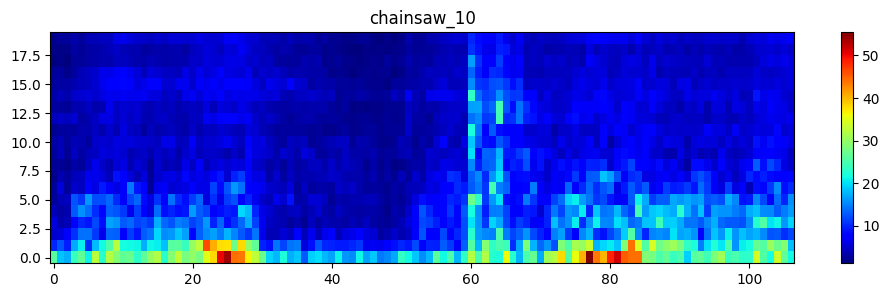

(1, 5)
Class predicted by KNN: chainsaw


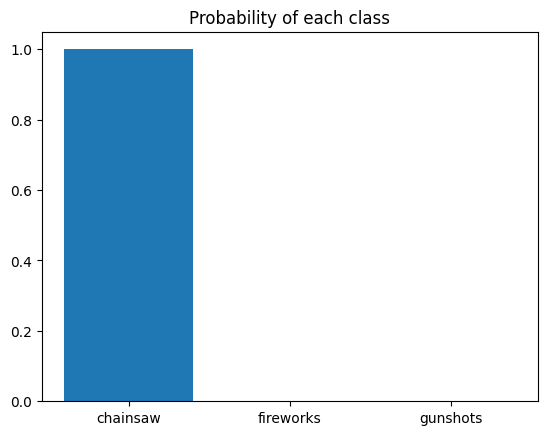

In [ ]:
### TO RUN
cls_index = ["chainsaw", 0]

if True:
    import sounddevice as sd
    print(sd.query_devices())
    sd.default.device = [1, 3]

myds.display(cls_index)
thisfv = myds.index_to_fv(cls_index)

# this artefact is necessary because the 'predict' function expects a matrix_like input.

mat = thisfv[0].reshape(1, -1)
prediction_knn = model_knn.predict(mat)
print("Class predicted by KNN:", prediction_knn[0])

proba_knn = model_knn.predict_proba(mat)
plt.figure()
plt.bar(classnames, proba_knn[0])
plt.title("Probability of each class")
plt.show()

**Question**:
When the classifier miss-predicts, how distributed is the probability vector? Is it good news? How can we exploit that probability distribution for the prediction?


<div style="color: #2e7d32;">

Lorsqu'un classifieur KNN réalise une mauvaise prédiction, le vecteur de probabilités présente généralement l'un des deux comportements suivants :

- **Forte incertitude / Entropie élevée (Probabilités distribuées) :** Les probabilités sont réparties de manière quasi égale entre plusieurs classes (ex: [0,35; 0,33; 0,32]). Le modèle hésite, ce qui indique que le vecteur de caractéristiques se situe près d'une frontière de décision ou dans une région peu couverte par les données d'entraînement.
- **Surconfiance :** Le modèle prédit la mauvaise classe avec une confiance élevée (ex: [0,85; 0,10; 0,05]), ce qui se produit lorsque du bruit ou des artéfacts imitent les caractéristiques d'une autre classe.

#### Une entropie élevée est-elle une bonne nouvelle ?
**Oui.** Lorsqu'une erreur de classification s'accompagne d'un vecteur de probabilités très distribué, cela signifie que le modèle est **bien calibré** : il « sait qu'il ne sait pas ». Une prédiction incertaine est beaucoup plus facile à gérer qu'une erreur commise avec une confiance absolue.

#### Comment exploiter cette distribution de probabilités :
1. **Seuil de rejet (*Rejection Threshold*) :** Définir un seuil de confiance $\max(\mathbb{P}\{i\}) < \tau$ (ex: $\tau = 0,5$). Si la probabilité maximale est inférieure à $\tau$, marquer la prédiction comme `"Incertaine"` ou `"Inconnue"`.
2. **Lissage temporel (Mémoire) :** Dans un flux audio continu, combiner les probabilités actuelles avec les prédictions passées pour réduire la volatilité trame par trame :
   $$\mathbb{P}_{\text{lissé}}(t) = \alpha \cdot \mathbb{P}(t) + (1 - \alpha) \cdot \mathbb{P}_{\text{lissé}}(t-1)$$
3. **Décision basée sur l'entropie :** Calculer l'entropie de Shannon $H(P) = -\sum P_i \log(P_i)$. Une entropie élevée déclenche des mécanismes de secours ou l'appel à un classifieur secondaire.

</div>


==> TrainSet et TestSet pas toujoiurs séparé donc parfois on a dans test un truc qu'on a déjà train

==> Dans KNN, on a mis que 5 voisins, ce qui n'est pas toujours assez 


<font size=6 color=#009999> 3.2. Successive inference </font> <br>

No matter if the predictions are one class only or probability vectors, as it is natural that consecutive feature vectors belong to the same class if the sound type changes slowlier than the duration of a feature vector, it can be helpful to link consecutive predictions and see how similar they are to either strengthen or decrease our confidence in the current guess. <br>

Here, we will compare the predictions made on consecutive feature vectors belonging to the same 5s-long sound. 
Run the following code with different ``class_id``'s and different ``num``.

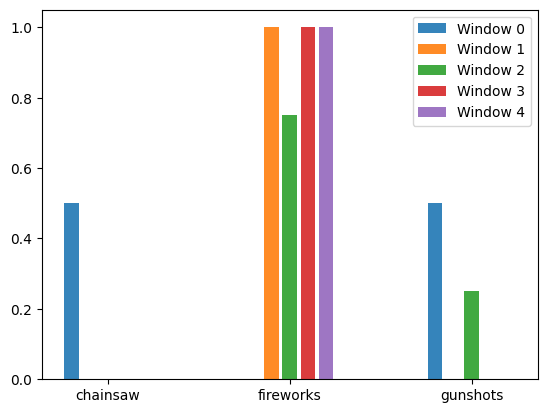

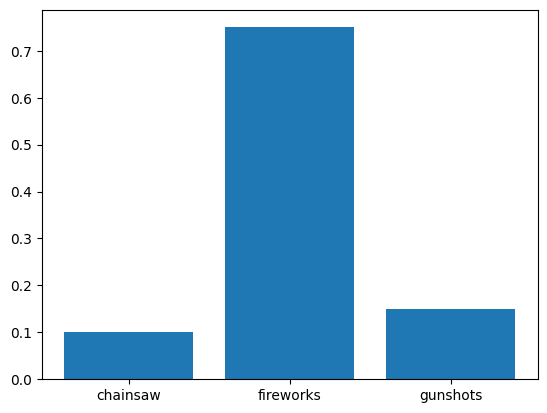

In [19]:
### TO RUN
num = 5  # 0 (default), 1, ..., 39

sound = dataset["chainsaw", num]
audio = AudioUtil.open(sound)
audio = AudioUtil.resample(audio, 11025)
AudioUtil.play(audio)

"Bar charts for each window"
n_win = 5
probs = np.zeros((n_win, len(classnames)))
for window in range(n_win):
    sub_aud = (audio[0][window * 11025 :], audio[1])
    sub_aud = AudioUtil.pad_trunc(sub_aud, 950)
    sgram = AudioUtil.melspectrogram(sub_aud, Nmel=20)
    ncol = int(1000 * 11025 / (1e3 * 512))
    sgram = sgram[:, :ncol]
    fv = sgram.reshape(-1)

    ### TO COMPLETE - Eventually normalize and reduce feature vector dimensionality
    if normalize:
        fv = (fv - np.mean(fv)) / np.std(fv)
    if pca is not None:
        fv = pca.transform([fv])[0]
        

    probs[window, :] = model_knn.predict_proba([fv])[0]

"Mean bar chart"
plt.figure()
for window in range(n_win):
    plt.bar(
        np.arange(len(classnames)) * 2 * n_win + window,
        probs[window, :],
        alpha=0.9,
        label=f"Window {window}",
    )
plt.legend()
plt.gca().set_xticks(np.arange(len(classnames)) * 2 * n_win + 2)
plt.gca().set_xticklabels(classnames)
plt.show()

plt.figure()
plt.bar(np.arange(len(classnames)), np.mean(probs, axis=0))
plt.gca().set_xticks(np.arange(len(classnames)))
plt.gca().set_xticklabels(classnames)
plt.show()

### Question:
Are the bar plots similar between the 5 windows of the same 5s-long sound? With the default sound, how often does the right class win?

<div style="color: #2e7d32;">

* **Similitude entre les 5 fenêtres :** **Non, ils ne sont pas tous similaires.**
  * Les fenêtres 1, 2, 3 et 4 prédisent très fortement la classe **`fireworks`** (avec une probabilité comprise entre $0,75$ et $1,0$).[cite: 2]
  * En revanche, la **fenêtre 0** se distingue nettement : la probabilité pour `fireworks` y est nulle, et l'incertitude est partagée à égalité ($0,5$) entre **`chainsaw`** et **`gunshots`**.

* **Fréquence de victoire de la bonne classe (`fireworks`) :** **4 fois sur 5 (soit 80 % du temps).**
  * La classe fireworks l'emporte dans 4 fenêtres individuelles sur 5.
  * En faisant la moyenne sur l'ensemble des fenêtres du signal, la classe `fireworks` ressort avec $0,75$ de probabilité globale.


BIZARRE CAR LA CLASSE CORRECTE EST CHAINSAW
</div>

If it is relevant to combine $N$ consecutive feature vectors, there are many ways to output a prediction from it:
- **Naive**: select the class that has the highest probability among all the considered feature vectors.
- **Majority voting**: simply select the class that appears most often as the maximum probability of a feature vector.
- **Average the feature representation**: compute the average of all feature vectors and classify from this average.
- **Maximum Likelihood**: take a probabilistic approach and consider selecting class $i$ as
    $$
        \text{argmax}_i~ \log \bigg(\prod_{n=0}^{N-1} P(y[n]=i) \bigg)
        = \text{argmax}_i~ \sum_{n=0}^{N-1} \log P(y[n]=i)
    $$
    with $y[n]$ the model prediction for the feature vector $n$.

It will be part of your work to decide how you want to exploit the time information in your predictions.

Now you have all the necessary material to test a new classification model and make some objective analysis of its performances. <br>
Follow the instructions on Moodle [written here](https://moodle.uclouvain.be/mod/assign/view.php?id=204607) to see what is expected in your ``first report``. <br>
A lot of other classification models are already implemented by SKlearn, check the [SKlearn API](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). Don't hesitate to read some opinions and discussions on the forums or even articles to help you in the model choice.<br>
Also, don't hesitate to get information from the Internet to learn how people deal with sound classification. We mention for example this idea of transfer learning that could be interesting for you in the second semester: https://www.youtube.com/watch?v=uCGROOUO_wY&t=1s 